<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC670 - Advanced Uses of Generative AI
## **Name:** Tim Hollis
## **Assignment:** Assessment 9.2
## **Date:** August 5, 2026

---

**References:**

Bahree, A. (2024). *Generative AI in action*. Manning Publications.

Bahree, A. (2024). *Listing 11.4: MLflow observability* [Source code]. GitHub. https://github.com/bahree/GenAIBook/blob/main/chapters/ch11/Listing-11.4_mlflow_observability.py

---

### **What This Notebook Recreates**

This notebook rebuilds Listing 11.4 from Bahree (2024), a minimal chat
application wrapped in MLflow observability. The application itself is
deliberately thin. What the listing is really demonstrating is that every call
to a language model is an event worth measuring, and that the measurement
belongs in the code path rather than bolted on afterward.

Three prerequisites differ from a plain script. The MLflow tracking server must
already be running at `localhost:5000` before any cell below executes. The API
key is read from a `.env` file rather than a shell variable, and the author's interactive
`while True` loop is replaced further down with a scripted conversation, because
a blocking `input()` call would hang the kernel and produce nothing in a
rendered PDF.

</div>

### **Initial Setup**

In [1]:
# Libraries/Imports
import os
import time

import mlflow
import tiktoken as tk
from colorama import Fore, Style, init
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI

# Load credentials from the .env file beside this notebook
load_dotenv(find_dotenv(), override=True)

# The listing expects OPENAI_API_BOOK_KEY, falling back to the standard name
API_KEY = os.getenv('OPENAI_API_BOOK_KEY') or os.getenv('OPENAI_API_KEY')

# Model and generation parameters, matching Listing 11.4
MODEL = 'gpt-3.5-turbo'
MLFLOW_URI = 'http://localhost:5000'
EXPERIMENT_NAME = 'GenAI_book'
TEMPERATURE = 0.7
TOP_P = 1
FREQUENCY_PENALTY = 0
PRESENCE_PENALTY = 0
MAX_TOKENS = 800
DEBUG = False

# Traces are captured on the server; the inline widget only breaks the PDF
mlflow.tracing.disable_notebook_display()

# Enable colored terminal output
init()

client = OpenAI(api_key=API_KEY)

# Point the client library at the local tracking server
mlflow.set_tracking_uri(MLFLOW_URI)
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

print('🔧 Configuring the observability stack')
print(f'   🔑 API key loaded: {bool(API_KEY)}')
print(f'   🤖 Model: {MODEL}')
print(f'   📦 mlflow {mlflow.__version__}   |   tiktoken {tk.__version__}')
print(f'   📡 Tracking URI: {mlflow.get_tracking_uri()}')
print(f'   🧪 Experiment: {experiment.name} (id {experiment.experiment_id})')
print('\n🚀 Setup complete, tracking server reachable')

🔧 Configuring the observability stack
   🔑 API key loaded: True
   🤖 Model: gpt-3.5-turbo
   📦 mlflow 3.15.1   |   tiktoken 0.13.0
   📡 Tracking URI: http://localhost:5000
   🧪 Experiment: GenAI_book (id 1)

🚀 Setup complete, tracking server reachable


In [2]:
# Print user input and AI output with colors
def print_user_input(text):
    print(f'{Fore.GREEN}You: {Style.RESET_ALL}', text)


def print_ai_output(text):
    print(f'{Fore.BLUE}AI Assistant:{Style.RESET_ALL}', text)


# Count tokens locally using the encoding the model family uses
def count_tokens(string: str, encoding_name='cl100k_base') -> int:
    encoding = tk.get_encoding(encoding_name)
    encoded_string = encoding.encode(string, disallowed_special=())
    num_tokens = len(encoded_string)
    return num_tokens


# Confirm the helpers behave before wiring them into the request path
sample = 'Observability is not the same thing as logging.'
print('🧰 Helper functions defined')
print(f'   🔢 count_tokens sample: {count_tokens(sample):,} tokens '
      f'for {len(sample):,} characters')
print_user_input('This is what a user turn looks like.')
print_ai_output('And this is what an assistant turn looks like.')

🧰 Helper functions defined
   🔢 count_tokens sample: 10 tokens for 47 characters
You:  This is what a user turn looks like.
AI Assistant: And this is what an assistant turn looks like.


### **The Instrumented Generation Function**

This is the center of the listing. Strip the observability out and it is a
single API call. Everything else exists to answer questions after the fact.

The author wraps the request in a wall-clock timer and logs the result as
`request_latency`. He then counts three separate token figures: the tokens in
the most recent user message, the tokens in the full conversation as a
serialized string, and the tokens in the completion. That third distinction is
easy to overlook and turns out to be the useful one. Prompt tokens grow with
every turn because the entire conversation is resent each time, so
`conversation_tokens` is what exposes the real cost curve of a chat session.
Watching only `prompt_tokens` would not show it.

A few implementation details are worth noting, less as criticism than as things
I had to work out while reading the code.

`request_count` is logged as the literal value 1 on every call. MLflow stores
repeated metric writes as a time series rather than accumulating them, so the
result is a series of ones stamped with the time of each request. Read as an
event marker that works, though a reader coming to the dashboard expecting a
running total would need to count points rather than read a value.

The generation parameters are logged as MLflow params inside the request
function, which means they are written on every call rather than once per run.
MLflow allows this as long as the value does not change, and here the constants
never do. It did make me think about what would happen if temperature became
adjustable mid-conversation, since params are designed to be set once.

Finally, `conversation_tokens` counts `str(conversation)`, which serializes the
Python list of dictionaries including braces, quotes, and role labels. The trend
that number shows is still the right shape, but the absolute value sits above
what the API actually bills for.

In [3]:
# Generate text using OpenAI API
def generate_text(conversation, max_tokens=100) -> str:
    # Wall-clock timing around the network call only
    start_time = time.time()
    response = client.chat.completions.create(
        model=MODEL,
        messages=conversation,
        temperature=TEMPERATURE,
        max_tokens=max_tokens,
        top_p=TOP_P,
        frequency_penalty=FREQUENCY_PENALTY,
        presence_penalty=PRESENCE_PENALTY,
    )
    latency = time.time() - start_time
    message_response = response.choices[0].message.content

    # Count tokens in the prompt and the completion
    prompt_tokens = count_tokens(conversation[-1]['content'])
    conversation_tokens = count_tokens(str(conversation))
    completion_tokens = count_tokens(message_response)

    run = mlflow.active_run()
    if DEBUG:
        print(f'Run ID: {run.info.run_id}')
        input('Press Enter to continue...')

    mlflow.log_metrics({
        'request_count': 1,
        'request_latency': latency,
        'prompt_tokens': prompt_tokens,
        'completion_tokens': completion_tokens,
        'conversation_tokens': conversation_tokens,
    })

    mlflow.log_params({
        'model': MODEL,
        'temperature': TEMPERATURE,
        'top_p': TOP_P,
        'frequency_penalty': FREQUENCY_PENALTY,
        'presence_penalty': PRESENCE_PENALTY,
    })
    return message_response


print('⚙️ generate_text defined, instrumentation wired in')
print('   📊 Metrics logged per call: request_count, request_latency, '
      'prompt_tokens, completion_tokens, conversation_tokens')
print('   🎛️ Params logged per call: model, temperature, top_p, '
      'frequency_penalty, presence_penalty')

⚙️ generate_text defined, instrumentation wired in
   📊 Metrics logged per call: request_count, request_latency, prompt_tokens, completion_tokens, conversation_tokens
   🎛️ Params logged per call: model, temperature, top_p, frequency_penalty, presence_penalty


### **Running the Application**

The author's entry point is a `while True` loop that calls `input()` and breaks
on exit, quit, q, or e. That works well in a terminal and not at all here.
A blocking `input()` call holds the kernel open, and nothing about the exchange
survives into a rendered PDF. The loop below keeps the same structure and
replaces the interactive prompt with a scripted list of turns, so the run is
reproducible and visible in the submitted document.

The conversation list itself is worth pausing on. It starts with a system
message and then accumulates both user and assistant turns, which is what makes
the exchange feel continuous to the model. It is also what makes each request
more expensive than the last, since the whole history travels with every call.

One line above the loop deserves attention. The author calls `mlflow.autolog()`
before opening the run. Autologging hooks into supported libraries and captures
calls without any explicit logging code, which means some of what lands in the
tracking server comes from the integration rather than from the `log_metrics`
calls written into `generate_text`. Separating those two sources is part of what
I wanted to see in the results.

In [4]:
# Scripted turns replace the author's interactive input() loop
SCRIPTED_TURNS = [
    'In two sentences, what is observability in a software system?',
    'How is that different from monitoring?',
    'Give me one concrete metric worth tracking for a chat application.',
]

mlflow.autolog()

with mlflow.start_run() as run:
    print(f'🏃 Run started: {run.info.run_id}')
    print(f'   🧪 Experiment id: {run.info.experiment_id}\n')

    conversation = [
        {'role': 'system', 'content': 'You are a helpful assistant.'},
    ]

    for turn, user_input in enumerate(SCRIPTED_TURNS, start=1):
        print(f'--- Turn {turn} ---')
        print_user_input(user_input)

        conversation.append({'role': 'user', 'content': user_input})
        ai_output = generate_text(conversation, MAX_TOKENS)
        print_ai_output(ai_output)
        conversation.append({'role': 'assistant', 'content': ai_output})

        print(f'   📈 Conversation now {count_tokens(str(conversation)):,} '
              f'tokens across {len(conversation):,} messages\n')

    final_run_id = run.info.run_id

print(f'✅ Run complete: {final_run_id}')
print(f'   🔗 View it at {MLFLOW_URI}')

2026/08/05 04:24:23 INFO mlflow.tracking.fluent: Autologging successfully enabled for openai.


🏃 Run started: 4efe814fd9a947e39b0689bd0167088f
   🧪 Experiment id: 1

--- Turn 1 ---
You:  In two sentences, what is observability in a software system?
AI Assistant: Observability in a software system refers to the ability to understand and monitor the internal state of the system based on its external outputs. It involves collecting and analyzing data from various sources to gain insights into the system's behavior and performance.
   📈 Conversation now 99 tokens across 3 messages

--- Turn 2 ---
You:  How is that different from monitoring?
AI Assistant: Monitoring typically focuses on tracking specific metrics or key performance indicators to ensure the system is functioning as expected, while observability goes beyond that by providing a deeper understanding of the system's internal workings and behaviors. Observability involves collecting data not just on predefined metrics but also on the system's overall state, allowing for more comprehensive troubleshooting and analysis.
   📈 

<div style="page-break-before: always;"></div>

### **Reading the Results Back**

Rather than only viewing the run in the browser, the cell below queries the
tracking server through the client API. Doing it this way makes the logged
values visible in the submitted notebook, and it shows what the metric history
actually looks like underneath the dashboard.

In [5]:
client = mlflow.MlflowClient()
run_data = client.get_run(final_run_id)

print(f'📋 Run {final_run_id}')
print(f'   Status: {run_data.info.status}')

print('\n🎛️ Params recorded once for the run')
for key, value in sorted(run_data.data.params.items()):
    print(f'   {key:<20} {value}')

print('\n📊 Final value of each metric')
for key, value in sorted(run_data.data.metrics.items()):
    print(f'   {key:<22} {value:,.4f}')

print('\n📈 Full metric history, one point per request')
for metric in ['request_count', 'request_latency', 'prompt_tokens',
               'completion_tokens', 'conversation_tokens']:
    history = client.get_metric_history(final_run_id, metric)
    values = [f'{h.value:,.2f}' for h in history]
    print(f'   {metric:<22} {len(history):>2,} points   {values}')

print('\n🔍 Traces captured by autolog rather than by explicit logging')
traces = mlflow.search_traces(locations=[run_data.info.experiment_id])
print(f'   Traces found: {len(traces):,}')

📋 Run 4efe814fd9a947e39b0689bd0167088f
   Status: FINISHED

🎛️ Params recorded once for the run
   frequency_penalty    0
   model                gpt-3.5-turbo
   presence_penalty     0
   temperature          0.7
   top_p                1

📊 Final value of each metric
   completion_tokens      48.0000
   conversation_tokens    218.0000
   prompt_tokens          12.0000
   request_count          1.0000
   request_latency        1.7118

📈 Full metric history, one point per request
   request_count           3 points   ['1.00', '1.00', '1.00']
   request_latency         3 points   ['1.18', '3.71', '1.71']
   prompt_tokens           3 points   ['13.00', '7.00', '12.00']
   completion_tokens       3 points   ['46.00', '67.00', '48.00']
   conversation_tokens     3 points   ['43.00', '118.00', '218.00']

🔍 Traces captured by autolog rather than by explicit logging
   Traces found: 10


### **The Trace View in the MLflow UI**

The metrics above were logged explicitly in `generate_text`. The view below was
not. Enabling `mlflow.autolog()` produced a full trace for each request,
capturing the token count, an estimated cost, the latency, and the message by
message exchange without any tracing code in the notebook.

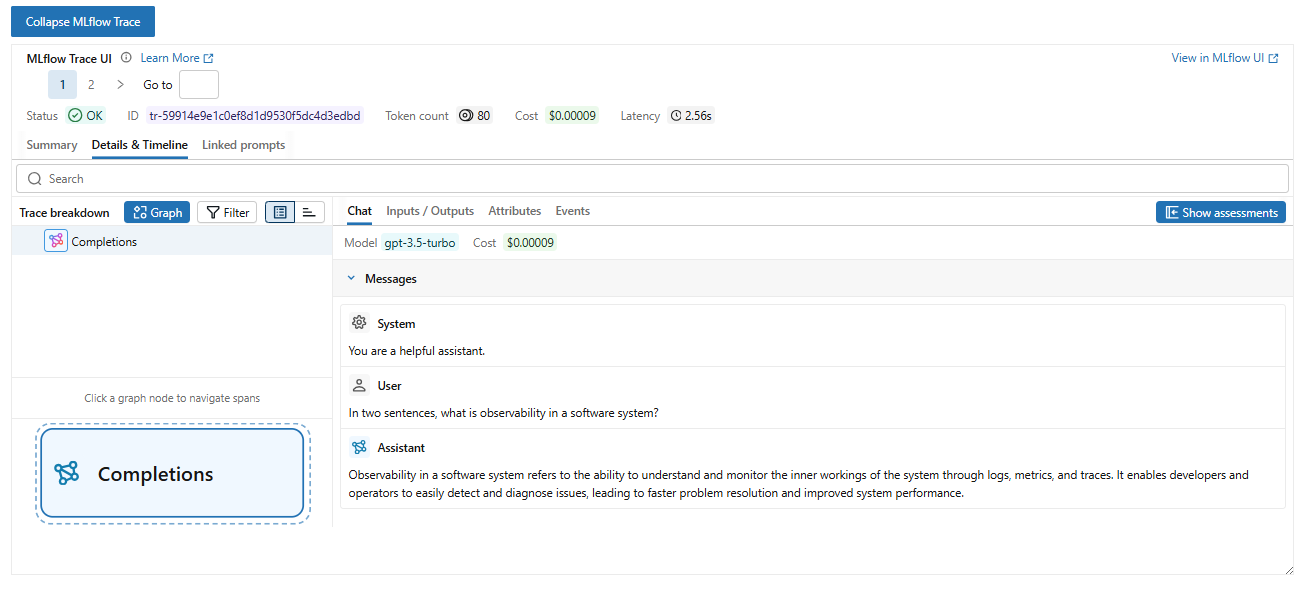

*Figure 1.* MLflow trace detail for a single request, captured from the tracking
server at `http://localhost:5000`. The screenshot was taken during an earlier
execution of this notebook, so its run identifier differs from the run recorded
in the cells above.

<div style="page-break-before: always;"></div>

### **Evaluation**

The listing does what it sets out to do, and running it surfaced a few things
the text does not cover.

The metric history makes the token argument concrete. Across three turns
`prompt_tokens` recorded 13, 7, and 12 while `conversation_tokens` moved from 43
to 118 to 218. Prompt tokens only ever describe the newest message, so that
figure drifts with however long the user happens to type and never trends
upward. The conversation figure roughly five-x'd in the space of three
exchanges, and it would keep climbing for as long as the session ran. Logging
both is the part of this listing I would carry into anything I built myself.
The loop output and the metric history report different figures for the same
turns, 99, 195, and 277 against 43, 118, and 218. The metric is written inside
`generate_text` before the assistant reply is appended, so it counts what was
sent, while my print statement runs after the append and counts what will be
sent on the following turn. Both are correct measurements of different moments,
which was a useful reminder that where an instrument sits in the code changes
what it reports.

Latency behaved less predictably than I expected. The three requests took 1.18,
3.71, and 1.71 seconds, so the slowest was the middle one. Lining that up
against `completion_tokens` at 46, 67, and 48 suggests the request that took
longest was simply the one that generated the most output. A single averaged
latency number would hide that relationship entirely, and it makes me think
latency is more useful when read next to output length than on its own.

`request_count` behaved as the metric history predicted, three points each
holding the value 1. MLflow treats repeated metric writes as a time series, so
this reads as a timestamped event marker rather than a running total. It is
usable, though a reader would need to count points rather than read a value.

The largest surprise came from `mlflow.autolog()`. The book was written against
an earlier MLflow release, and version 3.15.1 captures a full GenAI trace for
each call, including a token count, an estimated cost, the latency, and a
per-message view of the exchange, none of which the listing asks for. Figure 1
shows what that looks like in the tracking UI.

Querying for those traces taught me something about scoping. My search returned
ten traces rather than the three this run produced, because
`mlflow.search_traces` was pointed at the experiment rather than at a single run
and therefore returned everything the experiment had accumulated across repeated
executions. The metrics and the traces are stored against different keys, and I
had assumed they would come back together.

The wider lesson I am taking from this is that the two approaches answer
different questions. Instrumenting by hand forces a decision about what each
metric means, and a local token counter works anywhere, including against a
model that returns no usage data of its own. Autologging costs nothing to enable
and captured more than I would have thought to record. Seeing both in the same
run made the difference between them legible in a way that reading about either
one alone would not have.

# Reflection

## General Reflection
This week’s work in DSC670 centered on rebuilding Bahree’s Listing 11.4, and it ended up being far more about *observability design* than about writing a chat app. The assignment pushed me to think about what it means to measure a generative AI workflow from inside the code path rather than bolting metrics on afterward. Recreating the listing in a Jupyter Notebook made every logged value visible, and seeing the MLflow run evolve turn‑by‑turn clarified how quickly a chat session becomes expensive once the full conversation is resent on each request.

Two things stood out immediately. First, the distinction between prompt tokens and conversation tokens is not academic — it’s the difference between measuring the newest message and measuring the true cost curve of a chat session. As the notebook shows, “conversation_tokens moved from 43 to 118 to 218,” while prompt tokens stayed small and drifted only with message length. Second, autologging captured far more than the listing described. MLflow 3.15.1 generated full GenAI traces with token counts, estimated cost, latency, and message‑level detail without any explicit tracing code. Seeing explicit metrics and autolog traces side‑by‑side made the strengths and limitations of each approach obvious in a way the book alone couldn’t.

Overall, this assignment made observability feel concrete. It wasn’t just about logging numbers — it was about understanding *where* instrumentation sits, *what* it measures, and *how* those measurements shape the questions you can answer later.

## Straightforward Aspects
- Recreating the listing’s structure in a notebook was direct once the MLflow server was running and the environment variables were loaded.
- Implementing the token counter and latency timer was simple and behaved exactly as expected.
- Replacing the interactive loop with scripted turns made the run reproducible and allowed the metrics to appear cleanly in the PDF.
- Querying the run back through `MlflowClient` made it easy to verify that metrics and params were logged correctly.

## Challenging Aspects
- Understanding why prompt tokens and conversation tokens diverge required careful reading of the listing and validation through the metric history.
- Interpreting latency was less predictable — the longest request wasn’t the first or last, but the one with the largest completion.
- Autologging introduced traces I didn’t anticipate, and separating what came from explicit logging versus autolog required experimentation.
- Realizing that metric values differ depending on *when* they are counted (before or after appending the assistant turn) highlighted how sensitive observability is to instrumentation placement.
